# Load in the libs
### The function calls are all the same it is just the library that changes hence you only change the import library line

In [1]:
# Python Libs
import numpy as np
import matplotlib.pyplot as plt
import time
plt.style.use('dark_background')

import pwi_inst.hardware.SLM.MeadowlarkBlinkPlus.MeadowlarkBlinkPlusObject as slmlib
# import pwi_inst.hardware.SLM.MeadowlarkBlinkOverDrivePlus.MeadowlarkBlinkOneDrivePlusObject as slmlib
import pwi_inst.utils.GenerateSimplePhaseMasks as slm_masks
import pwi_inst.hardware.SLM.PhaseMaskClass as PhaseMaskClass
import pwi_inst.hardware.SLM.SLM_Server as SLM_Serverlib
import pwi_inst.hardware.SLM.SLM_Client as SLM_Clientlib
import pwi_inst.hardware.SLM.SLM_Viewer as SLM_Viewerlib
# import pwi_inst.utils.GenerateSimplePhaseMasks as slm_masks
# import pwi_inst.hardware.SLM.PhaseMaskClass as PhaseMaskClass

In [2]:
import pwi_inst.hardware.Cameras.FLIRPointGreyCameras.FLIR_PointGrey as CamLib


In [2]:
%load_ext autoreload
%aimport pwi_inst.hardware.SLM.MeadowlarkBlinkPlus.MeadowlarkBlinkPlusObject
# %aimport pwi_inst.hardware.SLM.MeadowlarkBlinkOneDrivePlus.MeadowlarkBlinkOneDrivePlusObject
%aimport pwi_inst.hardware.SLM.SLM_Server 
%aimport pwi_inst.hardware.SLM.SLM_Client
%aimport pwi_inst.hardware.SLM.SLM_Viewer
%aimport pwi_inst.hardware.SLM.PhaseMaskClass
%autoreload 1


In [4]:
# slmObj = SLM_Serverlib.SLMServerObject(SLMType="Blink Plus",LutFile="C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm7635_at532_30C.lut")
# slmObj.startProcess()
# print(slmObj.Process.is_alive())
# props = slmObj.GetProperties()
# viewer = SLM_Viewerlib.SLMOutputViewer(
#     shm_name=props["viewer_shared_memory_name"],
#     shape=props["viewer_shape"],
#     dtype=props["viewer_dtype"],
#     zoom=1.0,fps=1000,
# )
# viewer.startProcess()
# viewer.set_zoom(0.2)
# slmobj_client=SLM_Clientlib.SLMClientObject()
# # slmobj_client.LoadLutFile(b"C:\\Program Files\\Meadowlark Optics\\Blink Plus\\LUT Files\\slm7635_at532_30C.lut")
# phasemaskobj=PhaseMaskClass.PhaseMaskObject(SLMObject=slmobj_client, ActiveRGBChannels=["Red"], pixel_size = 17e-6, wavelength=1550e-9)


In [13]:
del slmobj_client

In [6]:
slmobj_client = SLM_Serverlib.SLMServerObject(SLMType="Blink Plus")
# shape = (1024, 1024, 1)
# slmobj_client.create_shared_memory(shape)

# slmobj_client.startProcess()

SLM process started PID 14136
SLM server ready
Shape: (1024, 1024, 1)
Input SHM: wnsm_53eabd98
Output SHM: wnsm_0bd96e87


In [ ]:
# del slmobj_client

In [14]:
slmobj_client=slmlib.SLMObject(board_number_in=1, RefreshRate=0,LutFile=None)
phasemaskobj=PhaseMaskClass.PhaseMaskObject(SLMObject=slmobj_client, ActiveRGBChannels=["Red"], pixel_size = 17e-6, wavelength=1550e-9)

Blink SDK constructed
Found 1 SLM controller(s)
Blink SDK constructed in parent (probe)
Found 1 controller(s)
Image size: 1024 x 1024, depth 8 bits (1 bytes/px)

        Zern Coefs:
        0:  piston    ( 0,  0 )
        1:  Tiltx     (1,  -1 )
        2:  Tilty     ( 1,  1 )
        3:  Astigx    (2,  -2 )
        4:  Defocus   ( 2,  0 )
        5:  Astigy    ( 2,  2 )
        6:  Trefilx   (3,  -3 )
        7:  Comax     (3,  -1 )
        8:  Comay     ( 1,  3 )
        9:  Trefoily  ( 3,  3 )
        12:  Spherical ( 4,  0 )
        
1024
1024
[  1   1 256 256]
Cleaning up resources...
Destroying


In [21]:
slmobj_client.wait_For_Trigger.value=100000
slmobj_client.timeout_ms=1000000

In [20]:
slmobj_client.SetRefreshRate(10e-3)

# Jitter test

=== Write Time ===
Mean:   11.285 ms
Std:    0.282 ms
Min:    10.673 ms
Max:    12.393 ms
Jitter: 1.720 ms

=== Loop Interval ===
Mean:   11.324 ms
Std:    0.283 ms
Min:    10.713 ms
Max:    12.421 ms
Jitter: 1.708 ms


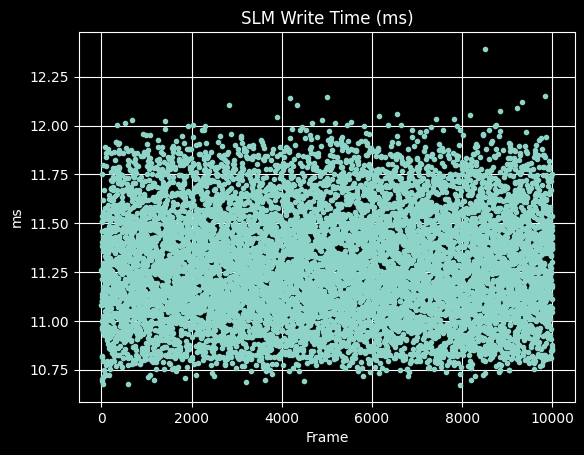

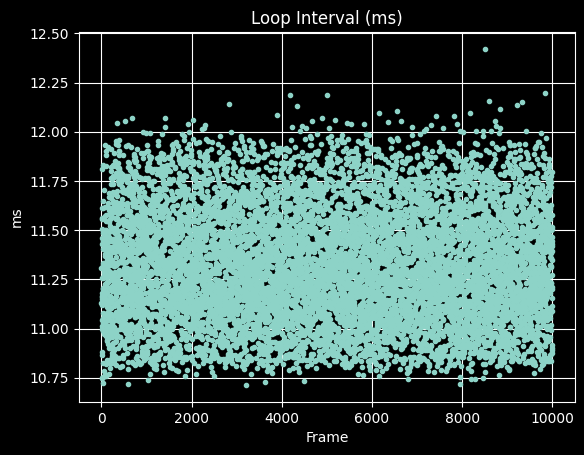

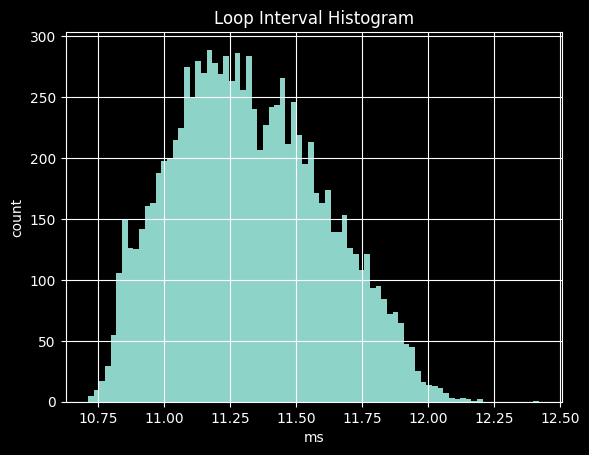

In [22]:
import time
import gc
import numpy as np
import matplotlib.pyplot as plt

n_frames = 10000

write_times = np.empty(n_frames, dtype=np.float64)
loop_intervals = np.empty(n_frames - 1, dtype=np.float64)

img = np.zeros(
    (slmobj_client.monitor_height, slmobj_client.monitor_width),
    dtype=np.uint8,
)

gc.disable()

last_t = None

try:
    for i in range(n_frames):
        # no allocation, no random generation
        img.fill(i % 255)

        t0 = time.perf_counter()

        if last_t is not None:
            loop_intervals[i - 1] = t0 - last_t

        slmobj_client.WriteImageToSLM(img, channelIdx=0)

        t1 = time.perf_counter()

        write_times[i] = t1 - t0
        last_t = t0

finally:
    gc.enable()

print("=== Write Time ===")
print(f"Mean:   {np.mean(write_times)*1e3:.3f} ms")
print(f"Std:    {np.std(write_times)*1e3:.3f} ms")
print(f"Min:    {np.min(write_times)*1e3:.3f} ms")
print(f"Max:    {np.max(write_times)*1e3:.3f} ms")
print(f"Jitter: {(np.max(write_times)-np.min(write_times))*1e3:.3f} ms")

print("\n=== Loop Interval ===")
print(f"Mean:   {np.mean(loop_intervals)*1e3:.3f} ms")
print(f"Std:    {np.std(loop_intervals)*1e3:.3f} ms")
print(f"Min:    {np.min(loop_intervals)*1e3:.3f} ms")
print(f"Max:    {np.max(loop_intervals)*1e3:.3f} ms")
print(f"Jitter: {(np.max(loop_intervals)-np.min(loop_intervals))*1e3:.3f} ms")

plt.figure()
plt.plot(write_times * 1e3, ".")
plt.title("SLM Write Time (ms)")
plt.xlabel("Frame")
plt.ylabel("ms")
plt.grid()
plt.show()

plt.figure()
plt.plot(loop_intervals * 1e3, ".")
plt.title("Loop Interval (ms)")
plt.xlabel("Frame")
plt.ylabel("ms")
plt.grid()
plt.show()

plt.figure()
plt.hist(loop_intervals * 1e3, bins=80)
plt.title("Loop Interval Histogram")
plt.xlabel("ms")
plt.ylabel("count")
plt.grid()
plt.show()

In [5]:
viewer.stopProcess()

In [8]:
del slmobj_client

In [10]:
slmobj_client=slmlib.SLMObject(board_number_in=1, RefreshRate=0,LutFile=None)
phasemaskobj=PhaseMaskClass.PhaseMaskObject(SLMObject=slmobj_client, ActiveRGBChannels=["Red"], pixel_size = 17e-6, wavelength=1550e-9)

Create_SDK failed: b'Image Flip Failed, No trigger supplied or DMA failed'


RuntimeError: No SLM controllers found

In [4]:
phasemaskobj.LCOS_Clean()

In [55]:
del Camobject

In [73]:
Camobject = CamLib.CameraObject(CameraIdx=0,verbose=True)

1 cameras detected:
0: FLIR camera 0
Using camera 0


In [134]:
slmobj_client.SetRefreshRate(50e-3)

In [50]:
Camobject.SetSoftwareTriggerMode()

('On', 'Software')

In [57]:
phasemaskobj.LCOS_Clean()

In [ ]:
slmobj_client.LoadLutFile()

In [95]:
check=bool(slmobj_client.WriteImageToSLM(np.zeros((1024,1024),dtype=np.uint8)))
print(check)
frame_NoStrip=Camobject.GetFrame()

True


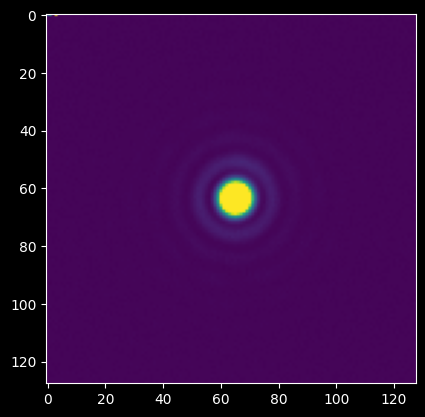

In [96]:
plt.imshow(frame_NoStrip)

True


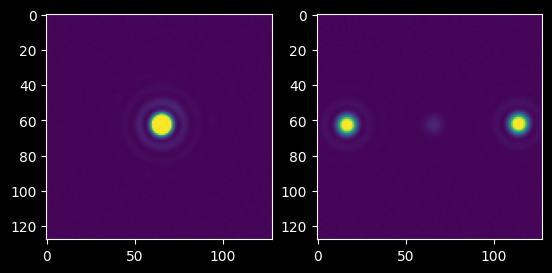

In [139]:
# phasemaskobj.LCOS_Clean()
check=bool(slmobj_client.WriteImageToSLM(np.zeros((1024,1024),dtype=np.uint8)))
check=bool(slmobj_client.WriteImageToSLM(np.zeros((1024,1024),dtype=np.uint8)))

frame_NoStrip=Camobject.GetFrame()
MaskCMPLX=slm_masks.binary_stripe_phase(Nx=1024,Ny=1024,stripe_width=16,phase_value=np.pi/2+0.0,orientation="vertical")

MaskInt=phasemaskobj.convert_phase_to_uint8( arr=(MaskCMPLX[0,0,:,:]))
check=bool(slmobj_client.WriteImageToSLM(MaskInt))
check=bool(slmobj_client.WriteImageToSLM(MaskInt))

print(check)
frame_Strip=Camobject.GetFrame()
plt.subplot(1,2,1)
plt.imshow(frame_NoStrip)
plt.subplot(1,2,2)
plt.imshow(frame_Strip)

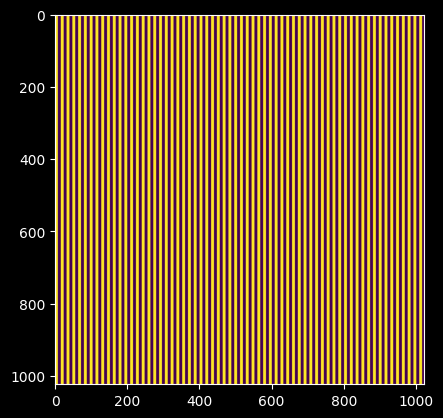

In [54]:
plt.imshow(MaskInt)

In [ ]:
MaskCMPLX=slm_masks.binary_stripe_phase(Nx=1024,Ny=1024,stripe_width=8,phase_value=0,orientation="vertical")
MaskInt=phasemaskobj.convert_phase_to_uint8( arr=(MaskCMPLX[0,0,:,:]))

In [ ]:

slmobj_client.GetSLMTemperature()
for i in range(10000):
    # make simple sprial mask that is the size of the display
    MaskCMPLX=slm_masks.binary_stripe_phase(Nx=1024,1024,stripe_width=8,phase_value=0,orientation="vertical")
    MaskInt=phasemaskobj.convert_phase_to_uint8( arr=(MaskCMPLX[0,0,:,:]))
    # MaskInt=np.angle(MaskCMPLX[0,0,:,:]).astype(np.uint8)
    # plt.imshow(MaskInt)
    # change the refresh rate and write the mask to the SLM
    slmobj_client.SetRefreshRate(10e-3)
    #Write the mask to the SLM
    check=bool(slmobj_client.WriteImageToSLM(MaskInt))
    # print(check) 

binary_stripe_phase(
    Nx: int,
    Ny: int,
    stripe_width: int = 8,
    phase_value: float = 0.0,
    orientation: str = "vertical",
)

# Make some full screen displays and load them on to the SLM while changeing the refresh rate

In [9]:

slmobj_client.GetSLMTemperature()
for i in range(10000):
    # make simple sprial mask that is the size of the display
    MaskCMPLX=slm_masks.SpiralMask(SpiralNum=i,Nx=slmobj_client.monitor_width,Ny=slmobj_client.monitor_height,pixelSize=17e-6, PlotMasks=False)
    MaskInt=phasemaskobj.convert_phase_to_uint8( arr=(MaskCMPLX[0,0,:,:]))
    # MaskInt=np.angle(MaskCMPLX[0,0,:,:]).astype(np.uint8)
    # plt.imshow(MaskInt)
    # change the refresh rate and write the mask to the SLM
    slmobj_client.SetRefreshRate(10e-3)
    #Write the mask to the SLM
    check=bool(slmobj_client.WriteImageToSLM(MaskInt))
    # print(check)


In [ ]:
slmobj_client.SetTriggerOutput(1)

1

: 

In [13]:
del slmobj_client

# Load a lut file

In [59]:

# slm.LoadLutFile(b"C:\\Program Files\\Meadowlark Optics\\Blink OverDrive Plus\\LUT Files\\1024x1024_linearVoltage.lut")
slmobj_client.LoadLutFile("C:\\Program Files\\Meadowlark Optics\\Blink Plus\\LUT Files\\slm7635_at532_30C.lut")


1

# Example of using the phase mask object that opens up more user friendly abilities

In [41]:

phasemaskobj=PhaseMaskClass.PhaseMaskObject(SLMObject=slm, ActiveRGBChannels=["Red"], pixel_size = 17e-6, wavelength=1550e-9)


        Zern Coefs:
        0:  piston    ( 0,  0 )
        1:  Tiltx     (1,  -1 )
        2:  Tilty     ( 1,  1 )
        3:  Astigx    (2,  -2 )
        4:  Defocus   ( 2,  0 )
        5:  Astigy    ( 2,  2 )
        6:  Trefilx   (3,  -3 )
        7:  Comax     (3,  -1 )
        8:  Comay     ( 1,  3 )
        9:  Trefoily  ( 3,  3 )
        12:  Spherical ( 4,  0 )
        
1024
1024
[  1   1 256 256]


# Load Pi flip masks

In [20]:
phasemaskobj.LoadPiFlipMasks(planeCount=1)

[  2   1 256 256]
[  2   1 256 256]


# Example of how to move Masks Around

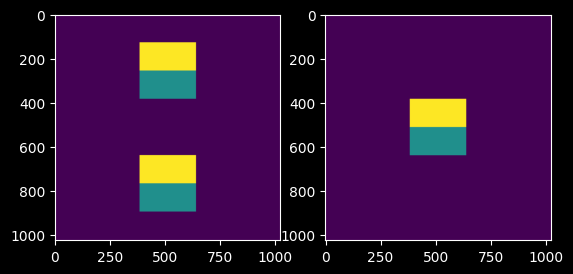

In [21]:


plt.subplot(1,2,1)
plt.imshow(phasemaskobj.FullScreenBuffer_int)
# trun the Vpol mask off
phasemaskobj.polProps["Red"]['V'].polEnabled=False
# move Hpol mask to center
phasemaskobj.AllMaskProperties["Red"]["H"][0].center[1] = 1024//2
phasemaskobj.AllMaskProperties["Red"]["H"][0].center[0] = 1024//2
phasemaskobj.setmask(channel="Red",imode=0)

plt.subplot(1,2,2)
plt.imshow(phasemaskobj.FullScreenBuffer_int)

# SLM Server Example

In [3]:
slmObj = SLM_Serverlib.SLMZMQServer()

In [4]:
slmObj.startProcess()


SLM server process started with PID 21028


In [ ]:

props = slmObj.GetProperties()

In [ ]:





from SLM_Output_Viewer import SLMOutputViewer

props = slmObj.GetProperties()

viewer = SLMOutputViewer(
    shm_name=props["viewer_shared_memory_name"],
    shape=props["viewer_shape"],
    dtype=props["viewer_dtype"],
    window_width=900,
    window_height=500,
    zoom=1.0,
)

viewer.startProcess()

viewer.startProcess()